모델 배포 개론 03  
Last modified : 2026.08   
작성 : 박광석 (모두의연구소)    
수정 : 김지성 (모두의연구소)

In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
# Colab의 nest_asyncio 방식 대신, macOS에서도 안정적인 표준 asyncio 루프를 사용합니다.
print("도우미 로딩 중...", flush=True)

import os, sys, asyncio, threading, time, socket, contextlib, subprocess, signal
from pathlib import Path

print("uvicorn import 중...", flush=True)
import uvicorn
print("uvicorn 준비 완료", flush=True)

# 작업 디렉터리를 DP03 루트(app/ 가 생길 위치)로 맞춥니다.
cwd = Path.cwd()
if (cwd / "DP03.ipynb").exists() or (cwd / "app").exists():
    pass
elif (cwd / "DP03" / "DP03.ipynb").exists():
    os.chdir(cwd / "DP03")
elif cwd.name == "notebooks" and (cwd.parent / "app").exists():
    os.chdir(cwd.parent)

for _d in ("app", "models", "data", "frontend"):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def _pids_on_port(port):
    """해당 포트를 LISTEN 중인 프로세스 PID 목록을 반환합니다."""
    try:
        # macOS에서 lsof가 오래 걸릴 수 있어 timeout을 둡니다.
        out = subprocess.check_output(
            ["lsof", "-nP", f"-iTCP:{port}", "-sTCP:LISTEN", "-t"],
            text=True,
            stderr=subprocess.DEVNULL,
            timeout=2,
        )
    except (subprocess.CalledProcessError, FileNotFoundError, subprocess.TimeoutExpired):
        return []
    pids = []
    for line in out.split():
        try:
            pid = int(line)
        except ValueError:
            continue
        if pid != os.getpid():
            pids.append(pid)
    return pids

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다. 같은 포트의 다른 프로세스도 종료합니다."""
    entry = _SERVERS.pop(port, None)
    if entry:
        server, thread = entry
        server.should_exit = True
        for _ in range(30):
            if not thread.is_alive():
                break
            time.sleep(0.1)
    for pid in _pids_on_port(port):
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            pass
    for _ in range(30):
        if not _port_open("127.0.0.1", port):
            break
        time.sleep(0.1)

def serve_in_thread(app, host="127.0.0.1", port=8000, log_level="warning"):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(":")[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(30):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    if _port_open(host, port):
        print(f"포트 {port}가 아직 사용 중입니다. 다른 서버를 종료한 뒤 다시 실행하세요.")
        return None
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop="asyncio")
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외(macOS 포함)는 기본 이벤트 루프를 사용합니다.
        if sys.platform == "win32":
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if getattr(server, "started", False) and _port_open(host, port):
            print(f"서버 실행됨: http://{host}:{port}")
            return server
        if not thread.is_alive():
            break
        time.sleep(0.25)
    print("서버가 시작되지 않았습니다. 위 로그를 확인하세요.")
    return server

print("서버 도우미 준비 완료 (serve_in_thread, stop_server)", flush=True)
print(f"작업 디렉터리: {Path.cwd()}", flush=True)

도우미 로딩 중...
uvicorn import 중...
uvicorn 준비 완료
서버 도우미 준비 완료 (serve_in_thread, stop_server)
작업 디렉터리: /Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP03


> **로컬(Mac) 환경 준비**
>
> Colab이 아니라면 아래를 한 번만 준비하면 됩니다.
>
> ```bash
> cd 06_Deployment/DP03
> python3 -m venv .venv
> source .venv/bin/activate
> pip install -r requirements.txt
> ```
>
> Cursor/VS Code에서 커널을 `.venv (Python 3.x)` 로 선택한 뒤, 위 도우미 셀부터 순서대로 실행하세요.
> 포트 8000이 다른 앱에 점유되어 있으면 `serve_in_thread`가 자동으로 정리합니다.


# Day 3 — 비동기 처리와 에러 핸들링
```
[동기 API 서버 — 모델 추론에 3초 소요]

요청 A (0초) → 추론 → 응답 (3초)
요청 B (0초) → 대기 → 추론 → 응답 (6초)
요청 C (0초) → 대기 → 대기 → 추론 → 응답 (9초)
```

I/O 바운드 vs CPU 바운드:
- I/O 바운드 (DB, 외부 API) → 비동기로 효율 극대화 가능
- **CPU 바운드 (모델 추론)** → 단순 async/await만으로는 해결 안 됨 → `run_in_executor` 필요

`async def` 안에서 동기 작업을 수행하면 이벤트 루프가 멈춰 다른 요청을 처리할 수 없습니다.


## 1. 동기 vs 비동기: 왜 API 서버에서 중요한가?

> **학습 목표**
> - 동기(Synchronous)와 비동기(Asynchronous)의 차이를 명확히 구분할 수 있습니다.
> - 모델 추론 API에서 동기 처리가 왜 심각한 병목이 되는지 설명할 수 있습니다.
> - FastAPI가 내부적으로 요청을 어떻게 처리하는지 흐름을 이해합니다.

### 1.1 지금까지의 흐름 복습

Day 2에서 완성한 API는 정상적으로 동작합니다.
한 명이 요청을 보내면, 정확한 결과가 돌아옵니다.

그런데 **동시에 여러 명이 요청을 보내면** 어떻게 될까요?

이것이 오늘의 핵심 질문입니다.

### 1.2 동기 처리: 한 번에 하나씩

동기(Synchronous) 처리는 **작업을 순서대로, 하나씩** 수행하는 방식입니다.
앞의 작업이 끝나야 다음 작업을 시작합니다.

일상적인 비유로 설명하겠습니다.

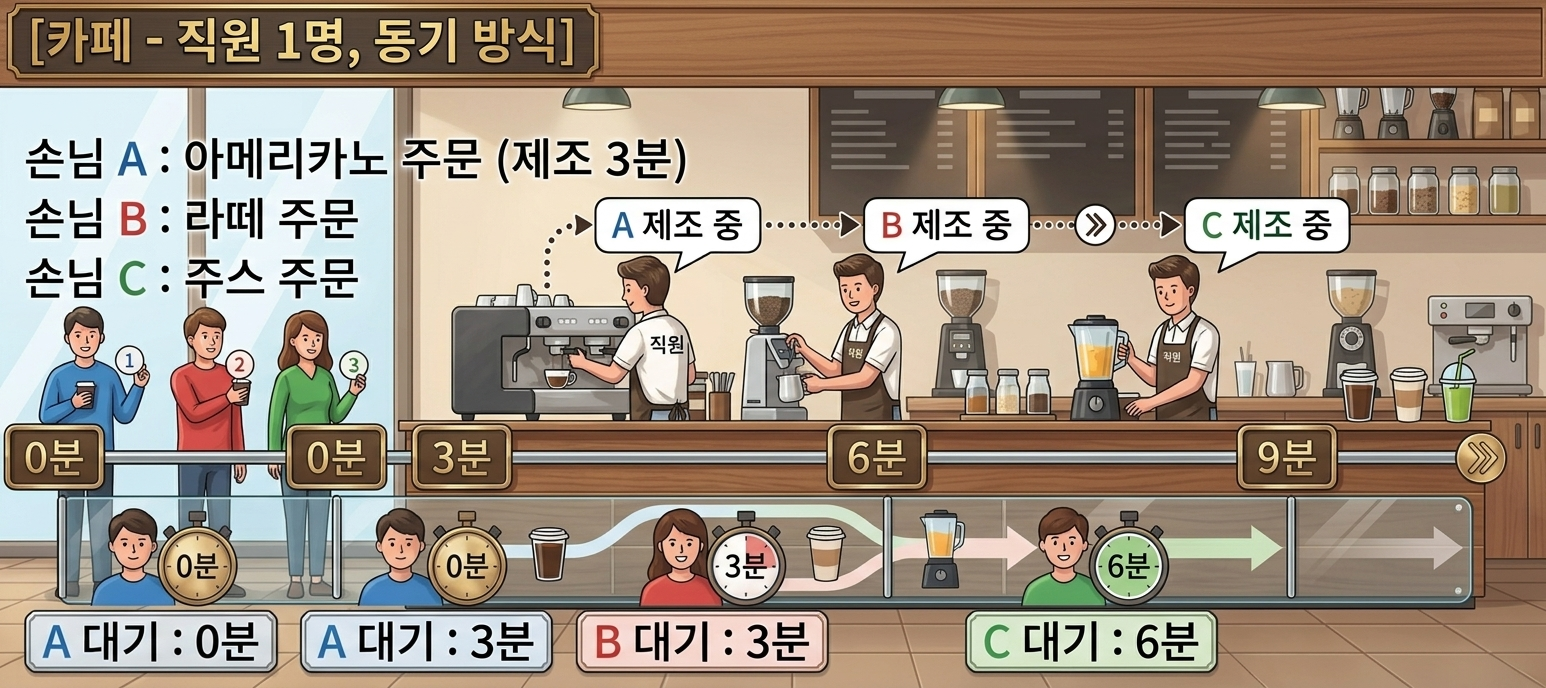

세 명의 고객(A, B, C)이 차례로 서 있으며, 각각 아메리카노, 라떼, 주스를 주문한 상태입니다.  
한 명의 바리스타가 주문을 하나씩 처리하고 있습니다.  
하단에 시간 표시(0분, 3분, 6분, 9분)는 고객 A는 대기 시간 0분, 고객 B는 3분, 고객 C는 6분 뒤에 음료를 받게 된다는 것을 시각적인 막대로 명확히 보여줍니다.

이것을 API 서버에 대입하면:



```
[동기 API 서버 — 모델 추론에 3초 소요]

요청 A 도착 (0초)  → 추론 시작 → 추론 완료 (3초) → 응답
요청 B 도착 (0초)  → 대기...                      → 추론 시작 (3초) → 응답 (6초)
요청 C 도착 (0초)  → 대기...                       → 대기...        → 추론 시작 (6초) → 응답 (9초)

시간축:
0초 ─────── 3초 ─────── 6초 ─────── 9초
 ███████████                              요청 A (3초 소요)
             ███████████                  요청 B (6초 대기 포함)
                          ███████████     요청 C (9초 대기 포함)
```


> 요청 B와 C는 서버가 바빠서가 아니라, **앞의 요청이 끝나기를 기다리느라** 느려진 것입니다.


### 1.3 비동기 처리: 대기 시간을 활용


비동기(Asynchronous) 처리는 **어떤 작업이 대기 상태일 때, 다른 작업을 처리**하는 방식입니다.


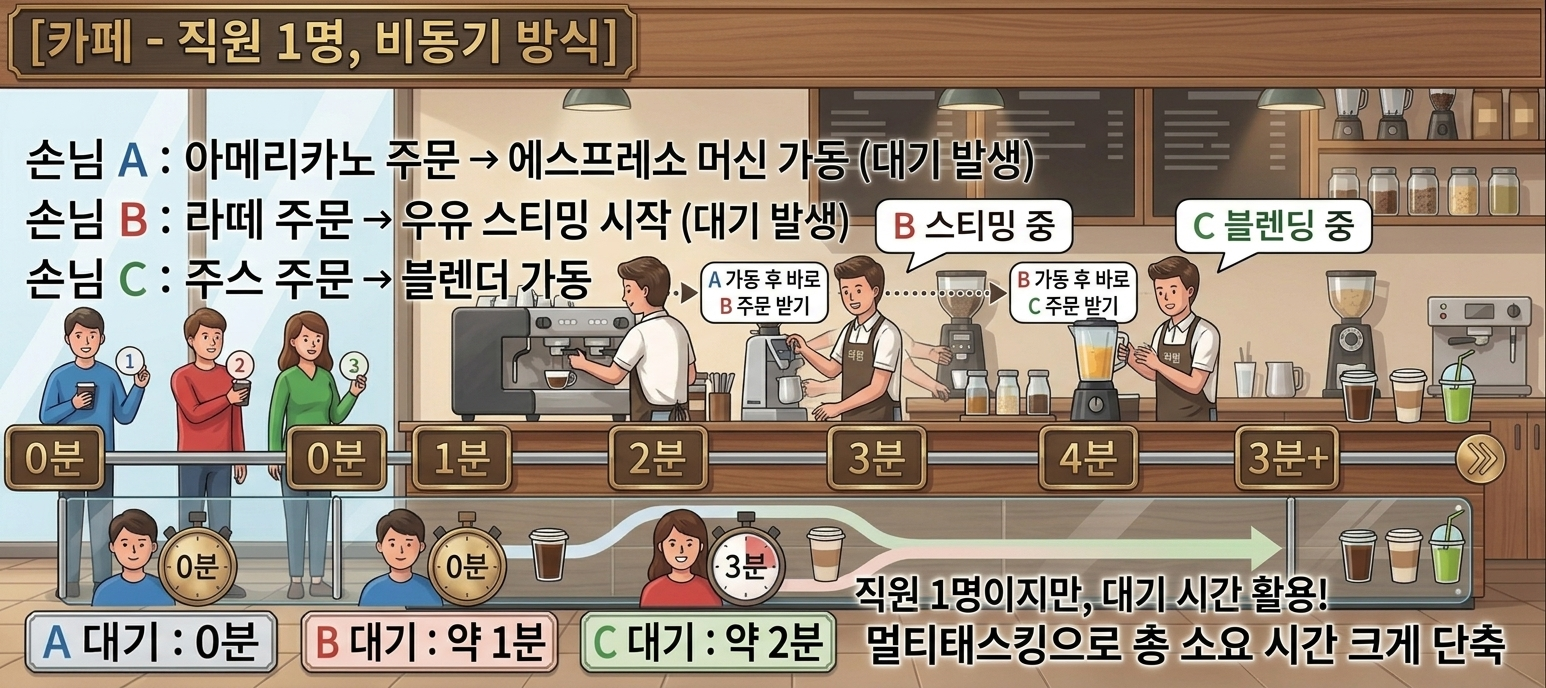

직원이 A의 주문을 받고 에스프레소 머신을 가동합니다.  
머신이 돌아가는 그 시간 동안, 직원은 B의 주문을 받습니다.  
  
직원은 B의 우유 스티밍을 시작합니다 (B 스티밍 중).  
머신(A 추출 중)과 스티밍(B 스티밍 중)이 동시에 돌아갑니다.  
직원은 C의 주문을 받습니다.  

직원은 C의 블렌더를 가동합니다 (C 블렌딩 중).  
머신(A), 스티머(B), 블렌더(C) 세 기계가 동시에 작동하고, 직원은 세 작업을 오갑니다.  

이렇게 9분이 걸리던 일을 3분만에 수행해내었습니다.  


> 비동기의 핵심은 **직원(CPU)을 늘리는 것이 아니라,
> 대기 시간에 놀지 않고 다른 일을 하는 것**입니다.


### 1.4 API 서버에서 "대기"란 무엇입니까?

웹 서버가 처리하는 작업은 크게 두 종류로 나뉩니다.


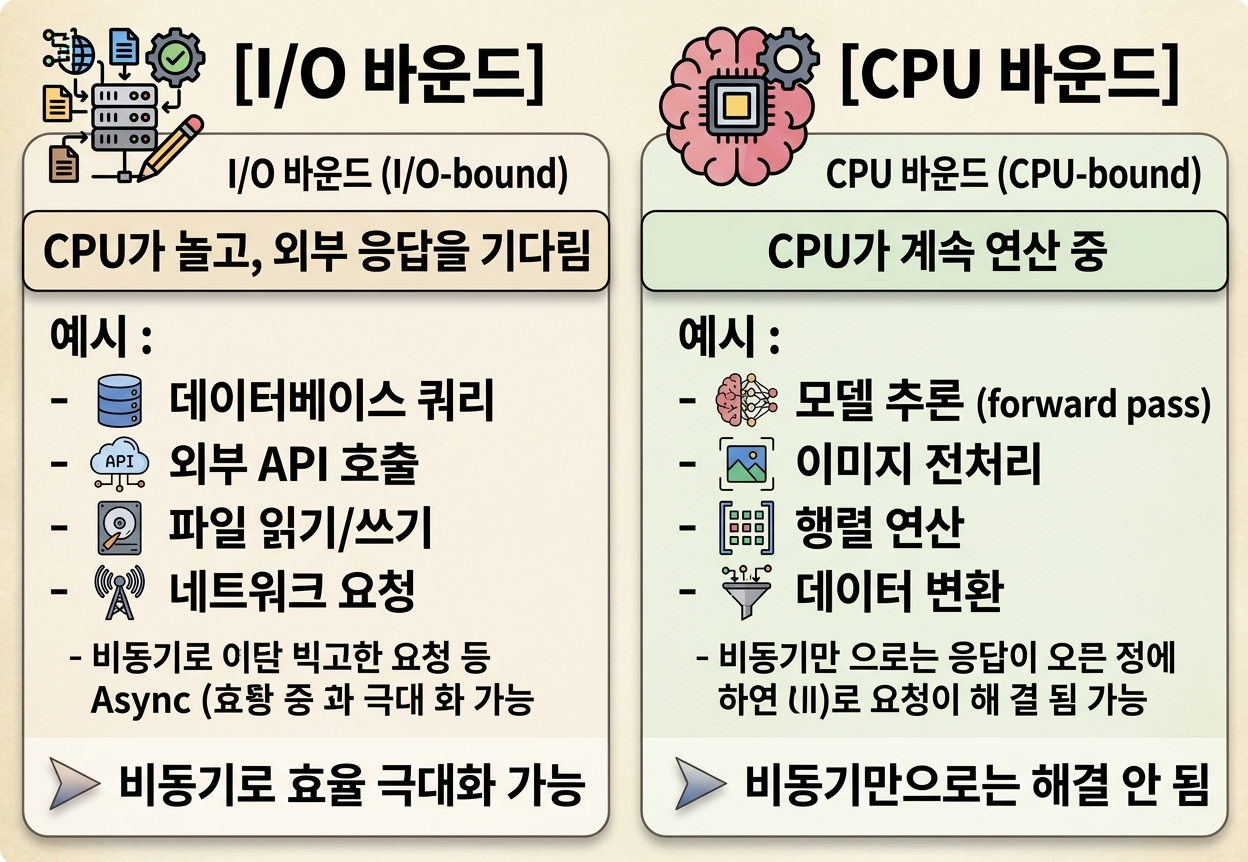


여기서 중요한 점이 있습니다:

> **모델 추론은 CPU 바운드 작업입니다.**

모델이 `forward()` 연산을 수행하는 동안 CPU(또는 GPU)는 쉬지 않고 계산합니다.
이 시간에 "다른 일을 할 수 있는 대기 시간"이 존재하지 않습니다.

그렇다면 비동기가 모델 추론에는 의미가 없을까요?
결론부터 말씀드리면, **의미가 있습니다**. 하지만 단순한 `async/await`만으로는 부족하고,
추가적인 패턴이 필요합니다. 이것이 오늘 섹션 4에서 다룰 `run_in_executor`입니다.


### 1.5 FastAPI의 요청 처리 방식

FastAPI가 내부적으로 요청을 어떻게 처리하는지 이해하면,
"왜 동기 추론이 문제인지"가 명확해집니다.



```
FastAPI는 내부적으로 단일 이벤트 루프(Event Loop)에서 동작합니다.

[이벤트 루프 — 단일 스레드]

  요청 A 도착 → 핸들러 실행 → ... → 응답 반환
  요청 B 도착 → (A가 끝날 때까지 대기) → 핸들러 실행 → ...
```

FastAPI는 함수의 정의 방식에 따라 다르게 동작합니다:


```python
# 방식 1: 일반 함수 (def)
@app.post("/predict")
def predict(request: PredictRequest):
    result = model(input_tensor)    # 이 동안 이벤트 루프가 블로킹되지 않음
    return result                   # FastAPI가 별도 스레드풀에서 실행해줌

# 방식 2: 비동기 함수 (async def)
@app.post("/predict")
async def predict(request: PredictRequest):
    result = model(input_tensor)    # ⚠️ 이 동안 이벤트 루프가 블로킹됨!
    return result                   # 다른 요청을 받을 수 없음
```



> ⚠️ **이것이 오늘의 핵심 함정입니다.**
>
> `async def`로 선언한 함수 안에서 **동기 작업(모델 추론)**을 수행하면,
> 이벤트 루프가 그 작업이 끝날 때까지 멈춥니다.
> 멈춰 있는 동안 다른 요청은 처리되지 않습니다.
>
> 반면 일반 `def`로 선언하면, FastAPI가 자동으로 별도 스레드에서 실행합니다.
> 하지만 이 방식은 스레드 수에 제한이 있어, 최적의 해결책은 아닙니다.

이 문제를 섹션 3에서 직접 재현하고, 섹션 4에서 해결하겠습니다.



### 1.6 정리: 오늘 풀어야 할 문제

 Day 2에서 만든 API는 한 번에 하나의 요청만 처리할 수 있습니다.  
모델 추론이 3초 걸린다면, 10명이 동시에 요청하면 마지막 사용자는 30초를 기다려야 합니다.             

해결 방향  
1. async/await의 원리를 이해한다 (섹션 2)  
2. 문제를 직접 재현한다 (섹션 3)  
3. run_in_executor로 해결한다 (섹션 4)  
4. 에러 핸들링으로 안정성을 높인다 (섹션 5)  
5. 개선 효과를 측정한다 (섹션 6)          

## 2. async/await의 기본 원리



> **학습 목표**
> - `async def`와 `await`의 의미를 코드로 이해합니다.
> - 동기 함수와 비동기 함수의 실행 시간 차이를 직접 비교합니다.

### 2.1 async/await란 무엇입니까?


```python
async def   → "이 함수는 비동기 함수입니다" (중간에 멈췄다가 다시 실행될 수 있음)
await       → "이 작업이 끝날 때까지 기다리되, 그 동안 다른 일을 해도 됩니다"
```

핵심 차이는 `time.sleep()` vs `asyncio.sleep()`입니다:

```
time.sleep(3)          → CPU를 3초간 점유. 그 동안 아무것도 할 수 없음.
await asyncio.sleep(3) → "3초 후에 깨워줘"라고 등록 후, 다른 작업 처리.
```

### 2.2 실습: 동기 vs 비동기 실행 시간 비교


위에 소개한 내용을 직접 확인해보겠습니다.  

In [2]:
import time
import asyncio

In [3]:
# 동기 방식: 순차 실행
def sync_task(name, seconds):
    print(f"  [{name}] 시작")
    time.sleep(seconds)
    print(f"  [{name}] 완료 ({seconds}초)")

print("===== 동기 실행 =====")
start = time.time()
sync_task("작업A", 2)
sync_task("작업B", 2)
sync_task("작업C", 2)
print(f"\n총 소요 시간: {time.time() - start:.1f}초")

===== 동기 실행 =====
  [작업A] 시작
  [작업A] 완료 (2초)
  [작업B] 시작
  [작업B] 완료 (2초)
  [작업C] 시작
  [작업C] 완료 (2초)

총 소요 시간: 6.0초


In [4]:
# 비동기 방식: 동시 실행
async def async_task(name, seconds):
    print(f"  [{name}] 시작")
    await asyncio.sleep(seconds)
    print(f"  [{name}] 완료 ({seconds}초)")

async def run_async():
    print("===== 비동기 실행 =====")
    start = time.time()
    await asyncio.gather(
        async_task("작업A", 2),
        async_task("작업B", 2),
        async_task("작업C", 2),
    )
    print(f"\n총 소요 시간: {time.time() - start:.1f}초")

await run_async()

===== 비동기 실행 =====
  [작업A] 시작
  [작업B] 시작
  [작업C] 시작
  [작업A] 완료 (2초)
  [작업B] 완료 (2초)
  [작업C] 완료 (2초)

총 소요 시간: 2.0초


결과를 비교합니다:

```
동기: 2초 + 2초 + 2초 = 6초 (순차 실행)
비동기: max(2초, 2초, 2초) = 2초 (동시 실행)
```


> `await`를 만나면, 이벤트 루프는 대기를 등록하고 바로 다음 작업을 시작합니다.  
> 세 작업의 "시작"이 거의 동시에 출력된 것이 그 증거입니다.

위에서 논의한 내용을 짧게 정리해보겠습니다  

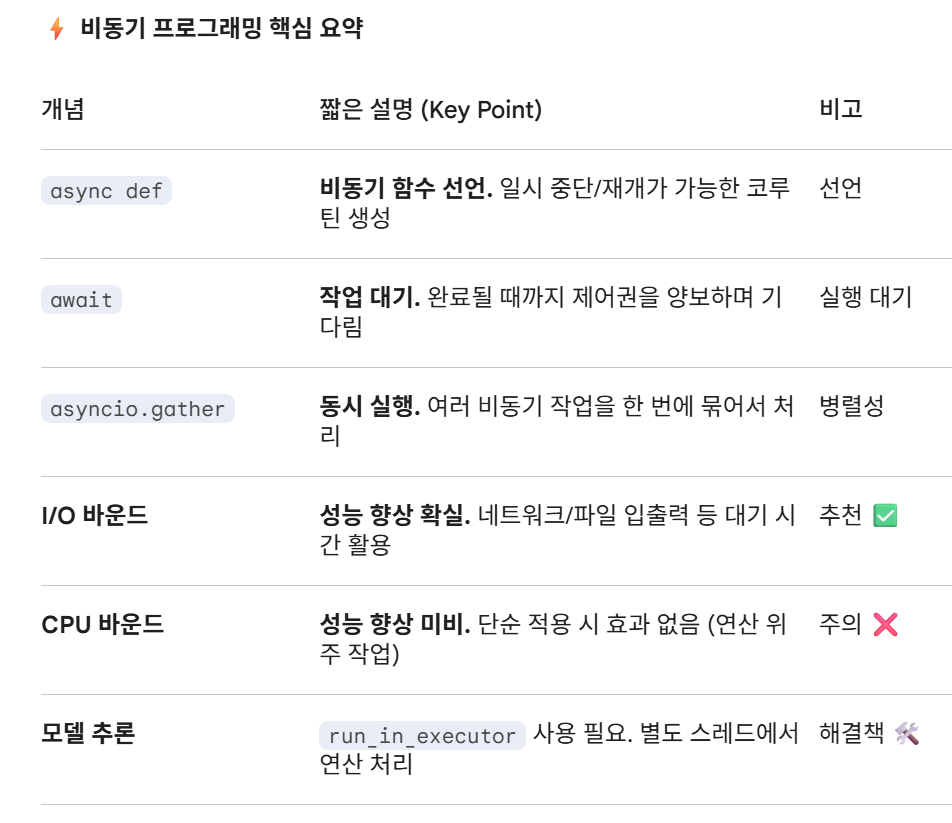

### ✅ 체크포인트

1. `time.sleep(3)`과 `await asyncio.sleep(3)`의 핵심 차이는 무엇입니까?
2. 모델 추론처럼 CPU를 계속 사용하는 작업에서 `async/await`만으로 동시 처리가 안 되는 이유는 무엇입니까?

## 3. 문제 시연: 동기 추론이 서버를 멈추는 순간

---

> **학습 목표**
> - 동기 추론이 서버에 미치는 영향을 실제 코드로 재현합니다.
> - 동시 요청 시 응답 시간이 어떻게 누적되는지 측정합니다.
> - `def`와 `async def`의 동작 차이를 실험으로 확인합니다.

### 3.1 실험 설계

문제를 명확하게 보여주기 위해, 의도적으로 **추론 시간이 긴 서버**를 만들겠습니다.

실제 모델 추론 대신 `time.sleep()`으로 추론 지연을 시뮬레이션합니다.
이렇게 하면 추론 시간을 정확히 통제할 수 있어 실험 결과가 깔끔합니다.

In [5]:
%%writefile app/main_sync_problem.py
"""
Day 3 - 섹션 3: 동기 추론의 문제점을 보여주는 서버
두 가지 버전의 엔드포인트를 비교합니다.
"""
import time
from fastapi import FastAPI

app = FastAPI(title="Sync vs Async Problem Demo")

INFERENCE_TIME = 3   # 추론에 3초 걸린다고 가정

# ===== 버전 1: async def 안에서 동기 작업 (문제 있음) =====
@app.post("/predict/blocking")
async def predict_blocking():
    """
    ⚠️ 문제 버전: async def 안에서 time.sleep (동기 블로킹)
    이벤트 루프가 멈추므로, 동시 요청을 처리할 수 없습니다.
    """
    time.sleep(INFERENCE_TIME)   # 동기 블로킹 — 이벤트 루프가 멈춤
    return {"result": "완료", "method": "blocking", "duration": INFERENCE_TIME}


# ===== 버전 2: 일반 def (FastAPI가 스레드풀에서 실행) =====
@app.post("/predict/threadpool")
def predict_threadpool():
    """
    일반 def: FastAPI가 자동으로 별도 스레드에서 실행합니다.
    이벤트 루프는 블로킹되지 않지만, 스레드풀 크기에 제한이 있습니다.
    """
    time.sleep(INFERENCE_TIME)
    return {"result": "완료", "method": "threadpool", "duration": INFERENCE_TIME}


# 헬스체크: 서버가 응답 가능한 상태인지 확인용
@app.get("/health")
async def health():
    return {"status": "healthy"}

Writing app/main_sync_problem.py


In [6]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.main_sync_problem:app", port=8000)

서버 실행됨: http://127.0.0.1:8000


---

### 3.2 실험 1: 동시 요청 시 blocking 엔드포인트의 문제

3개의 요청을 **동시에** 보내고, 각각의 응답 시간을 측정합니다.

In [7]:
import requests
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_request(url, request_id):
    """단일 요청을 보내고 소요 시간을 측정합니다."""
    start = time.time()
    response = requests.post(url)
    elapsed = time.time() - start
    return {
        "request_id": request_id,
        "elapsed": round(elapsed, 1),
        "status": response.status_code,
    }

def concurrent_test(url, n_requests=3):
    """n개의 요청을 동시에 보냅니다."""
    print(f"\n{'='*55}")
    print(f"  {n_requests}개 동시 요청 → {url}")
    print(f"{'='*55}")

    start = time.time()

    with ThreadPoolExecutor(max_workers=n_requests) as executor:
        futures = {
            executor.submit(send_request, url, i+1): i
            for i in range(n_requests)
        }

        results = []
        for future in as_completed(futures):
            results.append(future.result())

    total = time.time() - start

    # 결과 출력 (요청 ID순으로 정렬)
    for r in sorted(results, key=lambda x: x["request_id"]):
        print(f"  요청 #{r['request_id']}: {r['elapsed']}초")

    print(f"\n  전체 소요 시간: {round(total, 1)}초")
    return total

In [8]:
# 실험 1: blocking 엔드포인트 (async def + time.sleep)
total_blocking = concurrent_test("http://localhost:8000/predict/blocking", n_requests=3)


  3개 동시 요청 → http://localhost:8000/predict/blocking
  요청 #1: 3.0초
  요청 #2: 6.0초
  요청 #3: 9.0초

  전체 소요 시간: 9.0초


결과를 분석합니다:

```
추론 시간이 3초인데, 3개 동시 요청의 결과:

요청 #1: 3초  (즉시 처리)
요청 #2: 6초  (요청 #1이 끝날 때까지 3초 대기 + 추론 3초)
요청 #3: 9초  (요청 #1, #2가 끝날 때까지 6초 대기 + 추론 3초)

→ 완전한 순차 실행입니다. 동시 처리가 전혀 이루어지지 않았습니다.
```

> 어떤 요청이 먼저 처리되는지는 실행마다 달라질 수 있어, 요청 번호와 시간의 짝은 위 표와 다를 수 있습니다.
> 핵심은 세 요청이 3초/6초/9초로 **하나씩 차례로** 끝난다는 점입니다.

---

### 3.3 실험 2: threadpool 엔드포인트와 비교

In [9]:
# 실험 2: threadpool 엔드포인트 (일반 def)
total_threadpool = concurrent_test("http://localhost:8000/predict/threadpool", n_requests=3)


  3개 동시 요청 → http://localhost:8000/predict/threadpool
  요청 #1: 3.0초
  요청 #2: 3.0초
  요청 #3: 3.0초

  전체 소요 시간: 3.0초


결과를 비교합니다:

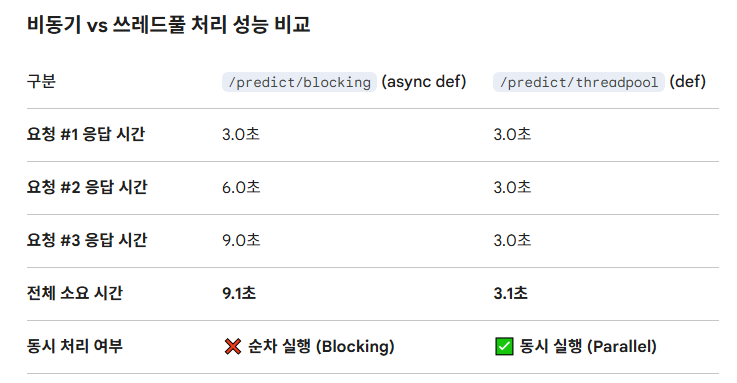

---

### 3.4 실험 3: blocking이 헬스체크까지 막는 현상

blocking 엔드포인트의 더 심각한 문제를 확인합니다.
추론 중에 헬스체크 요청이 들어오면 어떻게 될까요?

In [10]:
import threading

def test_health_during_inference(predict_url):
    """추론 중에 헬스체크가 응답하는지 테스트합니다."""

    results = {}

    def send_predict():
        start = time.time()
        requests.post(predict_url)
        results["predict"] = round(time.time() - start, 1)

    def send_health():
        time.sleep(0.5)   # 추론이 시작된 후 0.5초 뒤에 헬스체크
        start = time.time()
        resp = requests.get("http://localhost:8000/health")
        results["health"] = round(time.time() - start, 1)

    t1 = threading.Thread(target=send_predict)
    t2 = threading.Thread(target=send_health)
    t1.start()
    t2.start()
    t1.join()
    t2.join()

    return results

In [11]:
# blocking 버전
print("===== /predict/blocking 중 헬스체크 =====")
r = test_health_during_inference("http://localhost:8000/predict/blocking")
print(f"  추론 응답: {r['predict']}초")
print(f"  헬스체크 응답: {r['health']}초    ← 단순 상태 확인인데 2.5초 대기!")

print()

# threadpool 버전
print("===== /predict/threadpool 중 헬스체크 =====")
r = test_health_during_inference("http://localhost:8000/predict/threadpool")
print(f"  추론 응답: {r['predict']}초")
print(f"  헬스체크 응답: {r['health']}초    ← 즉시 응답!")

===== /predict/blocking 중 헬스체크 =====
  추론 응답: 3.0초
  헬스체크 응답: 2.5초    ← 단순 상태 확인인데 2.5초 대기!

===== /predict/threadpool 중 헬스체크 =====
  추론 응답: 3.0초
  헬스체크 응답: 0.0초    ← 즉시 응답!


> ⚠️ **blocking 버전에서는 헬스체크조차 대기합니다.**
>
> 이것이 실무에서 심각한 이유:
> - 로드밸런서는 헬스체크로 서버 상태를 판단합니다.
> - 헬스체크가 응답하지 않으면 "서버 다운"으로 판단하여 트래픽을 차단합니다.
> - 실제로는 서버가 살아있는데, 추론 때문에 응답을 못 하는 것뿐입니다.
> - 결과적으로 정상 서버가 풀에서 빠지는 심각한 문제가 발생합니다.

---

### 3.5 문제 원인 정리

```
[async def + 동기 작업의 문제]

async def predict_blocking():
    time.sleep(3)    ← 이벤트 루프 스레드에서 직접 실행
                        이벤트 루프가 3초간 완전히 멈춤
                        그 동안 다른 요청 처리 불가
                        헬스체크도 불가

[일반 def의 동작]

def predict_threadpool():
    time.sleep(3)    ← FastAPI가 별도 스레드풀(ThreadPoolExecutor)에서 실행
                        이벤트 루프는 자유로움
                        다른 요청 처리 가능
                        헬스체크 즉시 응답 가능
```

> 💡 **그러면 일반 def만 쓰면 되지 않습니까?**
>
> 일반 `def`를 사용하면 FastAPI가 기본 스레드풀에서 실행해줍니다.
> 이것만으로도 대부분의 경우 충분히 동작합니다.
>
> 하지만 두 가지 한계가 있습니다:
> 1. 기본 스레드풀 크기가 제한적입니다 (보통 40개).
> 2. 스레드풀 크기, 실행 방식을 직접 제어할 수 없습니다.
>
> 다음 섹션에서 배울 `run_in_executor` 패턴을 사용하면,
> 스레드풀을 명시적으로 제어하면서도 `async def`의 장점을 모두 활용할 수 있습니다.

---

### ✅ 체크포인트

1. `async def` 안에서 `time.sleep(3)`을 호출하면 왜 다른 요청까지 지연됩니까?
2. 일반 `def`로 선언된 엔드포인트는 FastAPI가 내부적으로 어떻게 처리합니까?
3. blocking 추론 중 헬스체크까지 막히면 실무에서 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** `run_in_executor` 패턴으로 이 문제를 해결합니다.
> `async def`의 장점을 유지하면서, 동기 작업도 이벤트 루프를 막지 않도록 만듭니다.

## 4. 해결 패턴: run_in_executor로 블로킹 방지하기

---

> **학습 목표**
> - `run_in_executor`의 동작 원리를 이해합니다.
> - 모델 추론을 이벤트 루프를 막지 않으면서 실행하는 패턴을 익힙니다.
> - ThreadPoolExecutor의 크기를 조절하는 방법을 알 수 있습니다.
> - Day 2에서 만든 API에 이 패턴을 적용할 수 있습니다.

### 4.1 run_in_executor란 무엇입니까?

`run_in_executor`는 **동기 함수를 별도 스레드(또는 프로세스)에서 실행**하고,
그 결과를 비동기적으로 기다리는 패턴입니다.

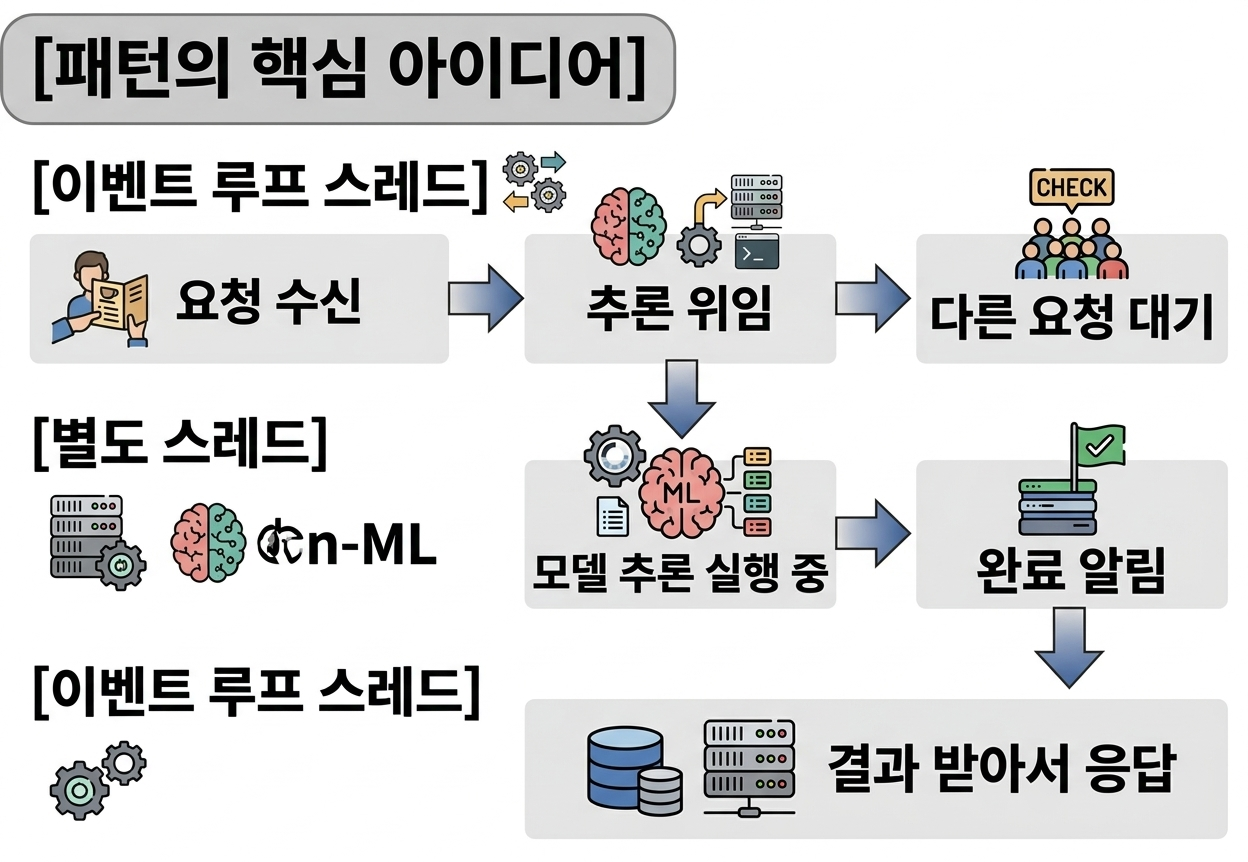



코드로 보면 단 한 줄입니다:

```python
import asyncio

# Before: 이벤트 루프를 막는 방식
async def predict_blocking():
    result = model(input_tensor)     # 이벤트 루프 멈춤
    return result

# After: 이벤트 루프를 막지 않는 방식
async def predict_non_blocking():
    loop = asyncio.get_running_loop()
    result = await loop.run_in_executor(
        None,                        # None = 기본 스레드풀 사용
        model,                       # 실행할 함수
        input_tensor,                # 함수에 전달할 인자
    )
    return result
```

> `await loop.run_in_executor(None, func, arg)`
>
> 이 한 줄이 하는 일:
> 1. `func(arg)`를 별도 스레드에서 실행합니다.
> 2. 이벤트 루프는 그 동안 다른 작업을 처리합니다.
> 3. `func`이 완료되면 결과를 반환합니다.

### 4.2 실습: 세 가지 버전 비교

섹션 3의 실험에 `run_in_executor` 버전을 추가하여 세 가지를 비교합니다.

In [12]:
%%writefile app/main_async_solution.py
"""
Day 3 - 섹션 4: 세 가지 동시 처리 방식 비교
"""
import time
import asyncio
from concurrent.futures import ThreadPoolExecutor
from fastapi import FastAPI

app = FastAPI(title="Async Solution Demo")

INFERENCE_TIME = 3

# 커스텀 스레드풀 생성 (최대 4개 스레드)
inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="inference")


def heavy_inference():
    """동기 함수: 모델 추론을 시뮬레이션합니다."""
    time.sleep(INFERENCE_TIME)
    return {"result": "완료", "duration": INFERENCE_TIME}


# ===== 버전 1: async def + 동기 작업 (문제 있음) =====
@app.post("/predict/v1-blocking")
async def predict_v1():
    """❌ 이벤트 루프를 막습니다."""
    time.sleep(INFERENCE_TIME)
    return {"method": "v1-blocking", "duration": INFERENCE_TIME}


# ===== 버전 2: 일반 def (FastAPI 자동 스레드풀) =====
@app.post("/predict/v2-def")
def predict_v2():
    """⭕ FastAPI가 자동으로 별도 스레드에서 실행합니다."""
    time.sleep(INFERENCE_TIME)
    return {"method": "v2-def", "duration": INFERENCE_TIME}


# ===== 버전 3: async def + run_in_executor (권장) =====
@app.post("/predict/v3-executor")
async def predict_v3():
    """✅ 명시적으로 스레드풀에 위임합니다."""
    loop = asyncio.get_running_loop()
    result = await loop.run_in_executor(
        inference_executor,    # 커스텀 스레드풀 사용
        heavy_inference,       # 실행할 동기 함수
    )
    return {"method": "v3-executor", **result}


@app.get("/health")
async def health():
    return {"status": "healthy"}

Writing app/main_async_solution.py


In [13]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.main_async_solution:app", port=8000)

서버 실행됨: http://127.0.0.1:8000


In [14]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

def concurrent_test(url, n_requests=3):
    """n개의 요청을 동시에 보내고 결과를 측정합니다."""
    def send(i):
        start = time.time()
        resp = requests.post(url)
        return {"id": i+1, "elapsed": round(time.time() - start, 1)}

    start = time.time()
    with ThreadPoolExecutor(max_workers=n_requests) as ex:
        futures = [ex.submit(send, i) for i in range(n_requests)]
        results = [f.result() for f in as_completed(futures)]
    total = round(time.time() - start, 1)

    for r in sorted(results, key=lambda x: x["id"]):
        print(f"  요청 #{r['id']}: {r['elapsed']}초")
    print(f"  전체: {total}초\n")
    return total

In [15]:
print("=" * 50)
print("버전 1: async def + time.sleep (blocking)")
print("=" * 50)
t1 = concurrent_test("http://localhost:8000/predict/v1-blocking")

버전 1: async def + time.sleep (blocking)
  요청 #1: 6.0초
  요청 #2: 3.0초
  요청 #3: 9.0초
  전체: 9.0초



In [16]:
print("=" * 50)
print("버전 2: 일반 def (FastAPI 자동 스레드풀)")
print("=" * 50)
t2 = concurrent_test("http://localhost:8000/predict/v2-def")

버전 2: 일반 def (FastAPI 자동 스레드풀)
  요청 #1: 3.0초
  요청 #2: 3.0초
  요청 #3: 3.0초
  전체: 3.0초



In [17]:
print("=" * 50)
print("버전 3: async def + run_in_executor (권장)")
print("=" * 50)
t3 = concurrent_test("http://localhost:8000/predict/v3-executor")

버전 3: async def + run_in_executor (권장)
  요청 #1: 3.0초
  요청 #2: 3.0초
  요청 #3: 3.0초
  전체: 3.0초



### 4.3 버전 2와 버전 3의 차이

결과만 보면 동일하지만, `run_in_executor`를 쓰는 핵심 이유가 있습니다:

```
일반 def (버전 2):
  → FastAPI 기본 스레드풀을 사용합니다.
  → 스레드풀 크기를 제어할 수 없습니다.
  → 다른 엔드포인트와 스레드풀을 공유합니다.

async def + run_in_executor (버전 3):
  → 추론 전용 스레드풀을 직접 만들어 사용합니다.
  → 크기를 제어할 수 있습니다 (max_workers=4).
  → 추론 부하가 다른 엔드포인트에 영향을 주지 않습니다.
```

> 간단한 프로젝트에서는 일반 `def`로 충분하지만,
> 추론 전용 스레드풀을 분리하고 싶다면 `run_in_executor`를 사용합니다.
> 이 과정에서는 `run_in_executor` 패턴을 기본으로 사용합니다.

### 4.4 Day 2 API에 적용하기

Day 2에서 만든 실제 추론 API(`app/main.py`)에 `run_in_executor`를 적용합니다.

In [18]:
%%writefile app/main_v2.py
"""
Day 3 - Day 2 API에 비동기 패턴 적용
app/main.py의 개선 버전입니다.
"""
import io
import base64
import asyncio
from concurrent.futures import ThreadPoolExecutor

import torch
import numpy as np
from PIL import Image
from fastapi import FastAPI, HTTPException

from app.schemas import (
    PixelPredictRequest,
    ImagePredictRequest,
    PredictResponse,
)
from app.model_utils import load_model, predict, preprocess


# ===== 앱 생성 =====
app = FastAPI(
    title="MNIST Prediction API (Async)",
    description="비동기 처리가 적용된 MNIST 추론 API",
    version="2.0.0",
)

# ===== 추론 전용 스레드풀 =====
inference_executor = ThreadPoolExecutor(
    max_workers=4,
    thread_name_prefix="inference",
)

# ===== 모델 로드 =====
MODEL_PATH = "models/mnist_state_dict.pth"
model = load_model(MODEL_PATH)


# ===== 동기 추론 함수 (스레드풀에서 실행될 함수) =====
def run_inference(image_tensor: torch.Tensor) -> dict:
    """모델 추론을 수행합니다. 이 함수는 별도 스레드에서 실행됩니다."""
    return predict(model, image_tensor)


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {"status": "healthy", "model_loaded": model is not None}


@app.post("/predict/pixels", response_model=PredictResponse, tags=["Inference"])
async def predict_from_pixels(request: PixelPredictRequest):
    """비동기 버전: 픽셀 배열로 추론"""
    try:
        # 전처리 (가벼운 작업 — 이벤트 루프에서 직접 수행)
        pixel_array = np.array(request.pixels, dtype=np.float32)
        pixel_tensor = torch.from_numpy(pixel_array)
        pixel_tensor = (pixel_tensor - 0.1307) / 0.3081
        pixel_tensor = pixel_tensor.unsqueeze(0).unsqueeze(0)

        # 추론 (무거운 작업 — 별도 스레드에서 실행)
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(
            inference_executor,
            run_inference,
            pixel_tensor,
        )

        return PredictResponse(
            success=True,
            predicted_class=result["predicted_class"],
            confidence=result["confidence"],
            probabilities=result["probabilities"] if request.return_probabilities else None,
        )

    except Exception as e:
        raise HTTPException(status_code=400, detail=f"추론 실패: {str(e)}")


@app.post("/predict/image", response_model=PredictResponse, tags=["Inference"])
async def predict_from_image(request: ImagePredictRequest):
    """비동기 버전: Base64 이미지로 추론"""
    try:
        # 전처리 (가벼운 작업)
        image_bytes = base64.b64decode(request.image_base64)
        image = Image.open(io.BytesIO(image_bytes))
        image_tensor = preprocess(image).unsqueeze(0)

        # 추론 (무거운 작업 — 별도 스레드에서 실행)
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(
            inference_executor,
            run_inference,
            image_tensor,
        )

        return PredictResponse(
            success=True,
            predicted_class=result["predicted_class"],
            confidence=result["confidence"],
            probabilities=result["probabilities"] if request.return_probabilities else None,
        )

    except base64.binascii.Error:
        raise HTTPException(status_code=400, detail="유효하지 않은 Base64 문자열입니다.")
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"이미지 처리 실패: {str(e)}")

Writing app/main_v2.py


변경된 부분을 정리합니다:

```
Day 2 (app/main.py)                    Day 3 (app/main_v2.py)
──────────────────                     ──────────────────────

def predict_from_pixels(...):          async def predict_from_pixels(...):
    ...                                    ...
    result = predict(model, tensor)        result = await loop.run_in_executor(
    ...                                        inference_executor,
                                               run_inference,
                                               tensor,
                                           )
                                           ...

변경: 2줄                               추가: inference_executor, run_inference
```

> 핵심 변경은 **추론 호출 한 줄**뿐입니다.
> 나머지 전처리, 검증, 에러 처리 코드는 그대로 유지됩니다.

### 4.5 스레드풀 크기 가이드

```
CPU 추론 (GPU 없음):
  - CPU 코어 수와 비슷하게 설정합니다.
  - 예: 4코어 → max_workers=4
  - 너무 많으면 컨텍스트 스위칭 오버헤드가 발생합니다.

GPU 추론:
  - GPU 메모리 제한이 있으므로 1~2로 설정합니다.
  - GPU는 내부적으로 병렬 처리하므로, 스레드를 늘려도 속도 향상이 크지 않습니다.
```

In [19]:
import os

# CPU 코어 수 확인
cpu_count = os.cpu_count()
print(f"CPU 코어 수: {cpu_count}")
print(f"권장 max_workers (CPU 추론): {cpu_count}")
print(f"권장 max_workers (GPU 추론): 1~2")

CPU 코어 수: 8
권장 max_workers (CPU 추론): 8
권장 max_workers (GPU 추론): 1~2


### 4.6 정리: 어떤 패턴을 선택해야 합니까?


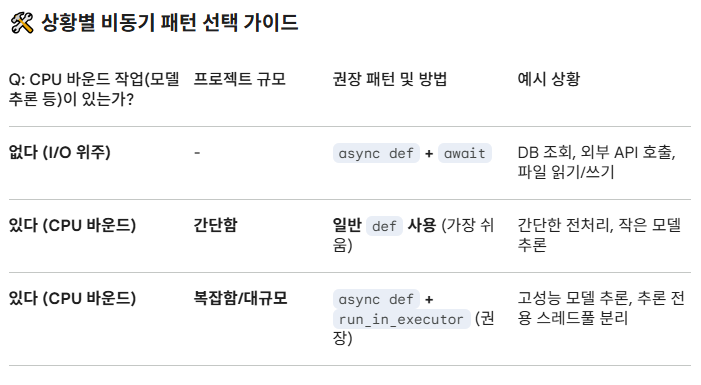


> 이 과정의 프로젝트에서는 `run_in_executor` 패턴을 사용합니다.
> 한번 익혀두면 실무에서도 그대로 적용할 수 있기 때문입니다.

---

### ✅ 체크포인트

1. `run_in_executor`가 이벤트 루프 블로킹을 방지하는 원리는 무엇입니까?
2. `run_in_executor`의 첫 번째 인자에 `None`을 넣으면 어떤 스레드풀이 사용됩니까?
3. 일반 `def`와 `async def + run_in_executor`의 핵심 차이는 무엇입니까?
4. GPU 추론 시 스레드풀 크기를 1~2로 제한하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 서버의 안정성을 높이기 위한 에러 핸들링과 로깅을 다룹니다.


## 5. 에러 핸들링과 로깅

---

> **학습 목표**
> - 예외 발생 시 서버가 죽지 않고, 안전한 에러 응답을 반환하는 구조를 만들 수 있습니다.
> - Python logging 모듈을 사용하여 로그를 남길 수 있습니다.

### 5.1 왜 에러 핸들링이 중요합니까?

입력이 올바르더라도 **서버 내부에서 에러가 발생**할 수 있습니다.

```
- 모델 파일이 손상되어 추론 중 에러 발생
- GPU 메모리 부족 (OOM)
- 이미지 디코딩 실패 (손상된 파일)
```

에러를 처리하지 않으면:

```
→ 스택 트레이스가 클라이언트에 노출 (보안 위험)
→ 에러 원인 추적 불가 (로그가 없음)

에러 핸들링 적용 후:
→ 서버 로그에 상세 정보 기록
→ 클라이언트에는 안전한 메시지만 반환
→ 서버는 계속 동작
```

### 5.2 글로벌 Exception Handler

매 엔드포인트마다 try/except를 반복하는 대신,
**글로벌 핸들러 하나**로 모든 예외를 중앙에서 처리합니다.

In [20]:
%%writefile app/error_handlers.py
"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )

Overwriting app/error_handlers.py


> 핵심 원칙:
> - **로그에는** 스택 트레이스, 요청 경로, 원본 에러 등 상세 정보를 기록합니다.
> - **클라이언트에게는** "서버 내부 오류가 발생했습니다"만 반환합니다.
> - 내부 코드 경로, 라이브러리 버전 등이 노출되면 보안 위험이 됩니다.

> 💡 **더 알고 싶다면**
>
> 실무에서는 커스텀 예외 클래스(`InferenceError`, `PreprocessError` 등)를 정의하여
> 에러 유형별로 다른 상태 코드를 반환하기도 합니다.
> 이 과정에서는 범용 핸들러 하나로 충분합니다.

### 5.3 Python logging 설정

`print()` 대신 `logging` 모듈을 사용해야 하는 이유:

```
print("에러 발생")           → 시간 정보 없음, 심각도 구분 없음, 파일 저장 불가

logger.error("에러 발생")    → 2024-01-15 14:30:22 ERROR [ml_api] 에러 발생
                               시간, 심각도, 모듈명이 자동 포함
```

In [21]:
%%writefile app/logger_config.py
"""
Day 3 - 로깅 설정
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger

Overwriting app/logger_config.py


> 실무에서는 파일 핸들러나 외부 로그 서비스(CloudWatch, Datadog 등)로
> 로그를 보내지만, 이 과정에서는 콘솔 로그로 충분합니다.

In [22]:
# 로거 테스트
from app.logger_config import setup_logger

logger = setup_logger("ml_api")

logger.info("서버가 시작되었습니다.")
logger.warning("GPU 메모리가 80%를 초과했습니다.")
logger.error("모델 추론 중 에러가 발생했습니다.")

2026-08-14 11:40:52 INFO     [ml_api] 서버가 시작되었습니다.
2026-08-14 11:40:52 WARNING  [ml_api] GPU 메모리가 80%를 초과했습니다.
2026-08-14 11:40:52 ERROR    [ml_api] 모델 추론 중 에러가 발생했습니다.


```
2024-01-15 14:30:22 INFO     [ml_api] 서버가 시작되었습니다.
2024-01-15 14:30:22 WARNING  [ml_api] GPU 메모리가 80%를 초과했습니다.
2024-01-15 14:30:22 ERROR    [ml_api] 모델 추론 중 에러가 발생했습니다.
```

로그 레벨의 의미:

```
INFO     → 정상 동작 기록 (서버 시작, 모델 로드 등)
WARNING  → 주의가 필요한 상황 (메모리 부족 임박 등)
ERROR    → 에러 발생 (추론 실패 등)
CRITICAL → 심각한 에러 (서버 다운 위험)
```

### 5.4 요청/응답 로깅 미들웨어

모든 요청과 응답을 자동으로 로깅하는 미들웨어입니다.
아래 코드를 그대로 사용하시면 됩니다.

In [23]:
%%writefile app/middleware.py
"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response

Overwriting app/middleware.py


이 미들웨어를 등록하면 서버 로그가 이렇게 보입니다:

```
2024-01-15 14:30:22 INFO     [ml_api] GET /health → 200 (0.001s)
2024-01-15 14:30:23 INFO     [ml_api] POST /predict/pixels → 200 (0.045s)
2024-01-15 14:30:24 WARNING  [ml_api] POST /predict/pixels → 422 (0.002s)
```

> 미들웨어는 `app.add_middleware(RequestLoggingMiddleware)`로 등록합니다.
> 섹션 6의 최종 서버 코드에서 실제로 적용합니다.

---

### ✅ 체크포인트

1. 글로벌 Exception Handler를 사용하면 어떤 반복을 줄일 수 있습니까?
2. 클라이언트에게 스택 트레이스를 노출하면 안 되는 이유는 무엇입니까?
3. `logging` 모듈이 `print()`보다 나은 점은 무엇입니까?

---

> **다음 섹션에서는** 오늘 배운 모든 내용을 종합하여,
> 동시 요청 테스트로 개선 효과를 직접 측정합니다.


## 6. 실습: 최종 서버 + 동시 요청 테스트

---

> **실습 목표**
> - 비동기 + 에러 핸들링 + 로깅이 적용된 최종 서버를 실행합니다.
> - 동시 요청 테스트로 동작을 확인합니다.
> - 에러 핸들링이 정상 동작하는지 확인합니다.

### 6.0 사전 준비: 의존 파일 확인  


이 섹션은 Day 1~3에서 생성한 파일들을 사용합니다.
아래 셀을 실행하면 필요한 파일이 있는지 확인하고, 없으면 자동으로 생성합니다.

> ⚠️ Day 1~3을 순서대로 진행한 분은 이 셀을 건너뛰어도 됩니다.
> 이 섹션부터 바로 시작하는 분만 실행하세요.

> **로컬(Mac)**: `../DP02/models/mnist_state_dict.pth` 가 있으면 학습 없이 복사합니다.

In [24]:
import os
import shutil
from pathlib import Path

# 필요한 폴더 생성
for d in ["app", "models", "data"]:
    os.makedirs(d, exist_ok=True)

MODEL_UTILS = r'''import torch
import torch.nn as nn
from torchvision import transforms

class SimpleClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

CLASS_NAMES = [str(i) for i in range(10)]

def load_model(model_path, num_classes=10):
    model = SimpleClassifier(num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
    model.eval()
    return model

def predict(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        idx = probs.argmax().item()
        return {
            "predicted_class": CLASS_NAMES[idx],
            "confidence": round(probs[idx].item(), 4),
            "probabilities": {CLASS_NAMES[i]: round(probs[i].item(), 4) for i in range(len(CLASS_NAMES))},
        }
'''

SCHEMAS = r'''from pydantic import BaseModel, Field, field_validator
from typing import Optional

class PixelPredictRequest(BaseModel):
    pixels: list[list[float]] = Field(..., description="28x28 픽셀 배열")
    return_probabilities: bool = Field(default=False)
    @field_validator("pixels")
    @classmethod
    def validate_pixels(cls, v):
        if len(v) != 28:
            raise ValueError(f"28행이어야 합니다. 현재: {len(v)}행")
        for i, row in enumerate(v):
            if len(row) != 28:
                raise ValueError(f"각 행은 28열이어야 합니다. {i}번째 행: {len(row)}열")
        return v

class ImagePredictRequest(BaseModel):
    image_base64: str = Field(..., min_length=1)
    return_probabilities: bool = Field(default=False)

class PredictResponse(BaseModel):
    success: bool = Field(description="성공 여부")
    predicted_class: str = Field(description="예측 숫자 (0~9)")
    confidence: float = Field(description="확신도", ge=0.0, le=1.0)
    probabilities: Optional[dict[str, float]] = Field(default=None)
'''

ERROR_HANDLERS = r'''import traceback, logging
from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")

def register_error_handlers(app: FastAPI):
    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        logger.error(f"에러: {type(exc).__name__}: {exc}\n경로: {request.method} {request.url}\n{traceback.format_exc()}")
        return JSONResponse(status_code=500, content={"success": False, "error": "서버 내부 오류가 발생했습니다."})
'''

LOGGER_CONFIG = r'''import logging, sys

def setup_logger(name="ml_api", level="INFO"):
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))
    if logger.handlers:
        return logger
    handler = logging.StreamHandler(sys.stdout)
    handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)-8s [%(name)s] %(message)s", "%Y-%m-%d %H:%M:%S"))
    logger.addHandler(handler)
    return logger
'''

MIDDLEWARE = r'''import time, logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")

class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request, call_next):
        start = time.time()
        response = await call_next(request)
        duration = round(time.time() - start, 3)
        msg = f"{request.method} {request.url.path} -> {response.status_code} ({duration}s)"
        if response.status_code >= 500: logger.error(msg)
        elif response.status_code >= 400: logger.warning(msg)
        else: logger.info(msg)
        response.headers["X-Process-Time"] = str(duration)
        return response
'''

# 1. app/model_utils.py (Day 1)
if not os.path.exists("app/model_utils.py"):
    print("⚠️ app/model_utils.py 없음 → 생성합니다.")
    with open("app/model_utils.py", "w", encoding="utf-8") as f:
        f.write(MODEL_UTILS)
    print("  ✅ app/model_utils.py 생성 완료")
else:
    print("✅ app/model_utils.py 있음")

# 2. app/schemas.py (Day 2)
if not os.path.exists("app/schemas.py"):
    print("⚠️ app/schemas.py 없음 → 생성합니다.")
    with open("app/schemas.py", "w", encoding="utf-8") as f:
        f.write(SCHEMAS)
    print("  ✅ app/schemas.py 생성 완료")
else:
    print("✅ app/schemas.py 있음")

# 3. app/error_handlers.py (Day 3 섹션 5)
if not os.path.exists("app/error_handlers.py"):
    print("⚠️ app/error_handlers.py 없음 → 생성합니다.")
    with open("app/error_handlers.py", "w", encoding="utf-8") as f:
        f.write(ERROR_HANDLERS)
    print("  ✅ app/error_handlers.py 생성 완료")
else:
    print("✅ app/error_handlers.py 있음")

# 4. app/logger_config.py (Day 3 섹션 5)
if not os.path.exists("app/logger_config.py"):
    print("⚠️ app/logger_config.py 없음 → 생성합니다.")
    with open("app/logger_config.py", "w", encoding="utf-8") as f:
        f.write(LOGGER_CONFIG)
    print("  ✅ app/logger_config.py 생성 완료")
else:
    print("✅ app/logger_config.py 있음")

# 5. app/middleware.py (Day 3 섹션 5)
if not os.path.exists("app/middleware.py"):
    print("⚠️ app/middleware.py 없음 → 생성합니다.")
    with open("app/middleware.py", "w", encoding="utf-8") as f:
        f.write(MIDDLEWARE)
    print("  ✅ app/middleware.py 생성 완료")
else:
    print("✅ app/middleware.py 있음")

# 6. 모델 파일 (Day 1 / 로컬이면 DP02 모델 재사용)
MODEL_PATH = Path("models/mnist_state_dict.pth")
DP02_MODEL = Path("../DP02/models/mnist_state_dict.pth")

if MODEL_PATH.exists():
    print("✅ models/mnist_state_dict.pth 있음")
elif DP02_MODEL.exists():
    shutil.copy2(DP02_MODEL, MODEL_PATH)
    print(f"✅ DP02 모델을 복사했습니다: {DP02_MODEL} → {MODEL_PATH}")
else:
    print("⚠️ 모델 파일 없음 → MNIST 모델을 학습하여 생성합니다. (약 1~2분 소요)")
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    from app.model_utils import SimpleClassifier

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_data = DataLoader(
        datasets.MNIST("data", train=True, download=True, transform=transform),
        batch_size=64,
        shuffle=True,
    )

    model = SimpleClassifier(10)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(2):
        for batch_idx, (images, labels) in enumerate(train_data):
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            if (batch_idx + 1) % 300 == 0:
                print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_data)}, Loss: {loss.item():.4f}")

    torch.save(model.state_dict(), MODEL_PATH)
    print("  ✅ models/mnist_state_dict.pth 생성 완료")

print("\n🎉 모든 의존 파일이 준비되었습니다. 다음 셀로 진행하세요.")

✅ app/model_utils.py 있음
✅ app/schemas.py 있음
✅ app/error_handlers.py 있음
✅ app/logger_config.py 있음
✅ app/middleware.py 있음
✅ models/mnist_state_dict.pth 있음

🎉 모든 의존 파일이 준비되었습니다. 다음 셀로 진행하세요.


### 6.1 최종 서버 코드 통합

Day 2 API에 오늘 배운 비동기 처리, 에러 핸들링, 로깅을 모두 적용한 최종 버전입니다.

In [25]:
%%writefile app/main_final.py
"""
Day 3 최종 버전 - 비동기 + 에러 핸들링 + 로깅
"""
import io
import base64
import asyncio
from concurrent.futures import ThreadPoolExecutor

import torch
import numpy as np
from PIL import Image
from fastapi import FastAPI, HTTPException

from app.schemas import PixelPredictRequest, ImagePredictRequest, PredictResponse
from app.model_utils import load_model, predict, preprocess
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


logger = setup_logger("ml_api")

app = FastAPI(
    title="MNIST Prediction API",
    description="비동기 처리, 에러 핸들링, 로깅이 적용된 MNIST 추론 API",
    version="3.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="inference")

MODEL_PATH = "models/mnist_state_dict.pth"
model = None


@app.on_event("startup")
async def startup():
    global model
    logger.info(f"모델 로드 중: {MODEL_PATH}")
    model = load_model(MODEL_PATH)
    logger.info("모델 로드 완료")


def run_inference(image_tensor: torch.Tensor) -> dict:
    """별도 스레드에서 실행되는 추론 함수"""
    if model is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return predict(model, image_tensor)


@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if model is not None else "loading",
        "model_loaded": model is not None,
    }


@app.get("/model/info", tags=["System"])
async def model_info():
    from app.model_utils import CLASS_NAMES
    total_params = sum(p.numel() for p in model.parameters())
    return {
        "model_name": "SimpleClassifier",
        "model_path": MODEL_PATH,
        "num_classes": len(CLASS_NAMES),
        "classes": CLASS_NAMES,
        "total_parameters": total_params,
    }


@app.post("/predict/pixels", response_model=PredictResponse, tags=["Inference"])
async def predict_from_pixels(request: PixelPredictRequest):
    try:
        pixel_array = np.array(request.pixels, dtype=np.float32)
        pixel_tensor = torch.from_numpy(pixel_array)
        pixel_tensor = (pixel_tensor - 0.1307) / 0.3081
        pixel_tensor = pixel_tensor.unsqueeze(0).unsqueeze(0)
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"전처리 실패: {str(e)}")

    try:
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(inference_executor, run_inference, pixel_tensor)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return PredictResponse(
        success=True,
        predicted_class=result["predicted_class"],
        confidence=result["confidence"],
        probabilities=result["probabilities"] if request.return_probabilities else None,
    )


@app.post("/predict/image", response_model=PredictResponse, tags=["Inference"])
async def predict_from_image(request: ImagePredictRequest):
    try:
        image_bytes = base64.b64decode(request.image_base64)
        image = Image.open(io.BytesIO(image_bytes))
        image_tensor = preprocess(image).unsqueeze(0)
    except base64.binascii.Error:
        raise HTTPException(status_code=400, detail="유효하지 않은 Base64 문자열입니다.")
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"이미지 처리 실패: {str(e)}")

    try:
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(inference_executor, run_inference, image_tensor)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return PredictResponse(
        success=True,
        predicted_class=result["predicted_class"],
        confidence=result["confidence"],
        probabilities=result["probabilities"] if request.return_probabilities else None,
    )

Writing app/main_final.py


> Day 2의 `app/main.py`와 비교했을 때 변경된 부분:
> - `async def` + `run_in_executor`로 추론 비동기화
> - `setup_logger`로 구조화된 로깅
> - `register_error_handlers`로 글로벌 에러 처리
> - `RequestLoggingMiddleware`로 모든 요청 자동 로깅

---

### 6.2 서버 실행 및 테스트

In [26]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.main_final:app", port=8000)

2026-08-14 11:40:55 INFO     [ml_api] 모델 로드 중: models/mnist_state_dict.pth
2026-08-14 11:40:55 INFO     [ml_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


#### 동시 요청 테스트

섹션 3에서 사용한 `concurrent_test()` 함수를 재사용하여 최종 서버를 테스트합니다.

In [27]:
import requests
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from torchvision import datasets

test_dataset = datasets.MNIST(root="data", train=False, download=True)

def concurrent_pixel_test(n_requests=3):
    """실제 모델 추론으로 동시 요청을 테스트합니다."""
    def send(i):
        image, label = test_dataset[i % len(test_dataset)]
        pixels = (np.array(image) / 255.0).tolist()
        start = time.time()
        resp = requests.post(
            "http://localhost:8000/predict/pixels",
            json={"pixels": pixels},
            timeout=30,
        )
        return {
            "id": i + 1,
            "elapsed": round(time.time() - start, 2),
            "status": resp.status_code,
        }

    print(f"\n{'='*50}")
    print(f"  {n_requests}개 동시 요청 (실제 추론)")
    print(f"{'='*50}")

    start = time.time()
    with ThreadPoolExecutor(max_workers=n_requests) as ex:
        futures = [ex.submit(send, i) for i in range(n_requests)]
        results = [f.result() for f in as_completed(futures)]
    total = round(time.time() - start, 2)

    for r in sorted(results, key=lambda x: x["id"]):
        print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
    print(f"  전체: {total}초")

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [28]:
# 동시 요청 수를 늘려가며 테스트
for n in [1, 2, 4, 8]:
    concurrent_pixel_test(n)
    time.sleep(1)


  1개 동시 요청 (실제 추론)
2026-08-14 11:41:29 INFO     [ml_api] POST /predict/pixels → 200 (0.038s)
  요청 #1: 0.04초 (HTTP 200)
  전체: 0.06초

  2개 동시 요청 (실제 추론)
2026-08-14 11:41:30 INFO     [ml_api] POST /predict/pixels → 200 (0.004s)
2026-08-14 11:41:30 INFO     [ml_api] POST /predict/pixels → 200 (0.005s)
  요청 #1: 0.01초 (HTTP 200)
  요청 #2: 0.01초 (HTTP 200)
  전체: 0.01초

  4개 동시 요청 (실제 추론)
2026-08-14 11:41:31 INFO     [ml_api] POST /predict/pixels → 200 (0.025s)
2026-08-14 11:41:31 INFO     [ml_api] POST /predict/pixels → 200 (0.024s)
2026-08-14 11:41:31 INFO     [ml_api] POST /predict/pixels → 200 (0.021s)
2026-08-14 11:41:31 INFO     [ml_api] POST /predict/pixels → 200 (0.023s)
  요청 #1: 0.04초 (HTTP 200)
  요청 #2: 0.04초 (HTTP 200)
  요청 #3: 0.04초 (HTTP 200)
  요청 #4: 0.03초 (HTTP 200)
  전체: 0.05초

  8개 동시 요청 (실제 추론)
2026-08-14 11:41:32 INFO     [ml_api] POST /predict/pixels → 200 (0.01s)
2026-08-14 11:41:32 INFO     [ml_api] POST /predict/pixels → 200 (0.014s)
2026-08-14 11:41:32 INFO     [ml_api]

---

### 6.3 에러 핸들링 동작 확인

In [ ]:
print("=" * 50)
print("  에러 핸들링 테스트")
print("=" * 50)

# 정상 요청
image, label = test_dataset[0]
pixels = (np.array(image) / 255.0).tolist()
resp = requests.post("http://localhost:8000/predict/pixels", json={"pixels": pixels})
print(f"\n[정상 요청] 상태: {resp.status_code}, 예측: {resp.json()['predicted_class']}")

# 잘못된 픽셀 크기
resp = requests.post(
    "http://localhost:8000/predict/pixels",
    json={"pixels": [[0.0] * 14 for _ in range(14)]}
)
print(f"[잘못된 크기] 상태: {resp.status_code}")

# 잘못된 Base64
resp = requests.post(
    "http://localhost:8000/predict/image",
    json={"image_base64": "not_valid!!!"}
)
print(f"[잘못된 Base64] 상태: {resp.status_code}, 에러: {resp.json().get('detail', 'N/A')}")

# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"[헬스체크] 상태: {resp.status_code}, 응답: {resp.json()}")

  에러 핸들링 테스트
2026-08-14 11:41:33 INFO     [ml_api] POST /predict/pixels → 200 (0.003s)

[정상 요청] 상태: 200, 예측: 7
2026-08-14 11:41:33 WARNING  [ml_api] POST /predict/pixels → 422 (0.001s)
[잘못된 크기] 상태: 422
2026-08-14 11:41:35 WARNING  [ml_api] POST /predict/image → 400 (2.362s)
[잘못된 Base64] 상태: 400, 에러: 이미지 처리 실패: cannot identify image file <_io.BytesIO object at 0x116148770>
2026-08-14 11:41:35 INFO     [ml_api] GET /health → 200 (0.0s)
[헬스체크] 상태: 200, 응답: {'status': 'healthy', 'model_loaded': True}


2026-08-14 14:46:38 WARNING  [ml_api] GET /api/case-studies → 404 (0.022s)
2026-08-14 16:27:03 WARNING  [ml_api] GET /api/case-studies → 404 (0.034s)
2026-08-14 16:27:03 WARNING  [ml_api] GET /api/case-studies → 404 (0.002s)
2026-08-14 16:29:01 WARNING  [ml_api] GET /api/case-studies → 404 (0.001s)
2026-08-14 16:29:01 WARNING  [ml_api] GET /api/case-studies → 404 (0.001s)
2026-08-14 16:36:17 WARNING  [ml_api] GET /api/case-studies → 404 (0.002s)
2026-08-14 16:36:17 WARNING  [ml_api] GET /api/case-studies → 404 (0.001s)
2026-08-14 16:40:22 WARNING  [ml_api] GET /api/case-studies → 404 (0.007s)
2026-08-14 16:40:22 WARNING  [ml_api] GET /api/case-studies → 404 (0.001s)
2026-08-14 16:45:10 WARNING  [ml_api] GET /api/case-studies → 404 (0.003s)
2026-08-14 16:46:36 WARNING  [ml_api] GET /api/case-studies → 404 (0.015s)
2026-08-14 16:46:42 WARNING  [ml_api] GET /api/case-studies → 404 (0.002s)
2026-08-14 16:47:44 WARNING  [ml_api] GET /api/case-studies → 404 (0.005s)
2026-08-14 16:50:01 WARNI

> 모든 비정상 요청이 **서버를 죽이지 않고**, 적절한 상태 코드와 메시지를 반환합니다.

---

### 6.4 프로젝트 구조 확인

```
model-serving-course/
├── 📁 app/
│   ├── error_handlers.py          ← Day 3: 글로벌 에러 핸들러
│   ├── logger_config.py           ← Day 3: 로깅 설정
│   ├── main_final.py              ← Day 3: 최종 서버
│   ├── middleware.py              ← Day 3: 요청/응답 로깅 미들웨어
│   ├── model_utils.py             ← Day 1: 모델 유틸리티
│   └── schemas.py                 ← Day 2: Pydantic 스키마
├── 📁 models/
│   └── mnist_state_dict.pth
├── .gitignore
└── requirements.txt
```

---

### ✅ Day 3 최종 체크포인트

```
Q1. 동기 서버에서 3초 걸리는 추론을 3명이 동시에 요청하면 총 몇 초 걸립니까?
Q2. time.sleep(3)과 await asyncio.sleep(3)의 핵심 차이는?
Q3. async def 안에서 동기 블로킹 코드를 실행하면 왜 헬스체크까지 영향받습니까?
Q4. run_in_executor가 이벤트 루프 블로킹을 방지하는 원리는?
Q5. 글로벌 Exception Handler를 사용하는 이유는?
Q6. 클라이언트에게 스택 트레이스를 노출하면 안 되는 이유는?
```

---

### 📌 Day 3 요약

```
오늘 한 일:
  ✅ 동기/비동기의 차이와 모델 추론에서의 의미를 이해했습니다.
  ✅ 동기 추론이 서버를 멈추는 문제를 재현하고 헬스체크 차단까지 관찰했습니다.
  ✅ run_in_executor 패턴으로 문제를 해결했습니다.
  ✅ 글로벌 에러 핸들러와 로깅으로 서버 안정성을 높였습니다.
  ✅ 동시 요청 테스트로 동작을 확인했습니다.

내일 (Day 4):
  🔜 Streamlit으로 웹 UI를 만들고 FastAPI와 연결합니다.
```

### 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 각 섹션 실행 스샷
2. 각 섹션 체크포인트의 답변

수고하셨습니다!